# load data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
train_df = pd.read_csv('../data/fashion-mnist_train.csv')
test_df  = pd.read_csv('../data/fashion-mnist_test.csv')

print(f"Train shape: {train_df.shape}")   # (60000, 785)
print(f"Test shape : {test_df.shape}")    # (10000, 785)

# Tách label và features
X_train = train_df.iloc[:, 1:].values     # (60000, 784)
y_train = train_df.iloc[:, 0].values      # (60000,)

X_test  = test_df.iloc[:, 1:].values
y_test  = test_df.iloc[:, 0].values

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Train shape: (60000, 785)
Test shape : (10000, 785)
X_train shape: (60000, 784), y_train shape: (60000,)


# train class distribution

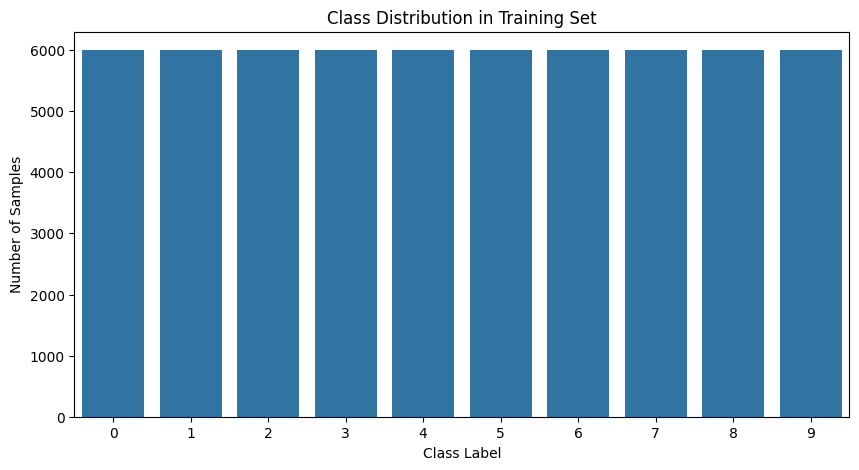

{np.int64(0): np.int64(6000), np.int64(1): np.int64(6000), np.int64(2): np.int64(6000), np.int64(3): np.int64(6000), np.int64(4): np.int64(6000), np.int64(5): np.int64(6000), np.int64(6): np.int64(6000), np.int64(7): np.int64(6000), np.int64(8): np.int64(6000), np.int64(9): np.int64(6000)}


In [3]:
import seaborn as sns

# Class distribution in train set
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train)
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

# Kiểm tra số lượng từng lớp
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))   # Nên ra 6000 cho mỗi lớp

# test class distribution

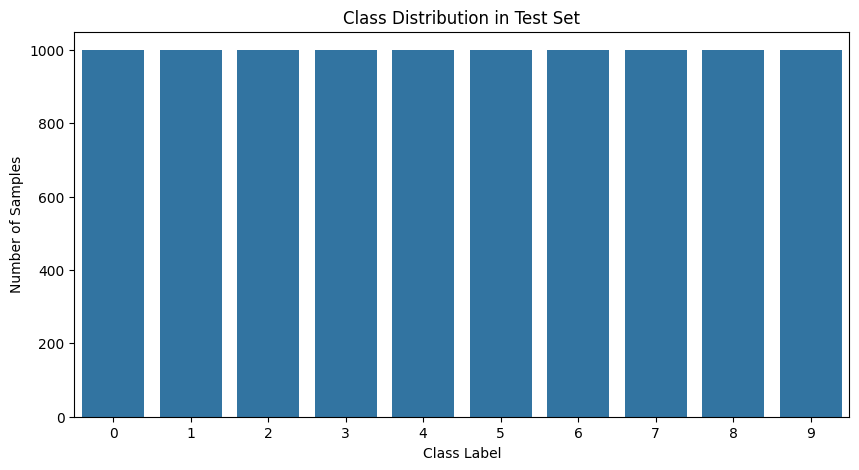

Test set class counts:
{np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(1000), np.int64(3): np.int64(1000), np.int64(4): np.int64(1000), np.int64(5): np.int64(1000), np.int64(6): np.int64(1000), np.int64(7): np.int64(1000), np.int64(8): np.int64(1000), np.int64(9): np.int64(1000)}


In [7]:
# Class distribution in test set
plt.figure(figsize=(10, 5))
sns.countplot(x=y_test)
plt.title('Class Distribution in Test Set')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.show()

# Kiểm tra số lượng từng lớp trong test set
unique_test, counts_test = np.unique(y_test, return_counts=True)
print("Test set class counts:")
print(dict(zip(unique_test, counts_test)))

# train vs test distribution

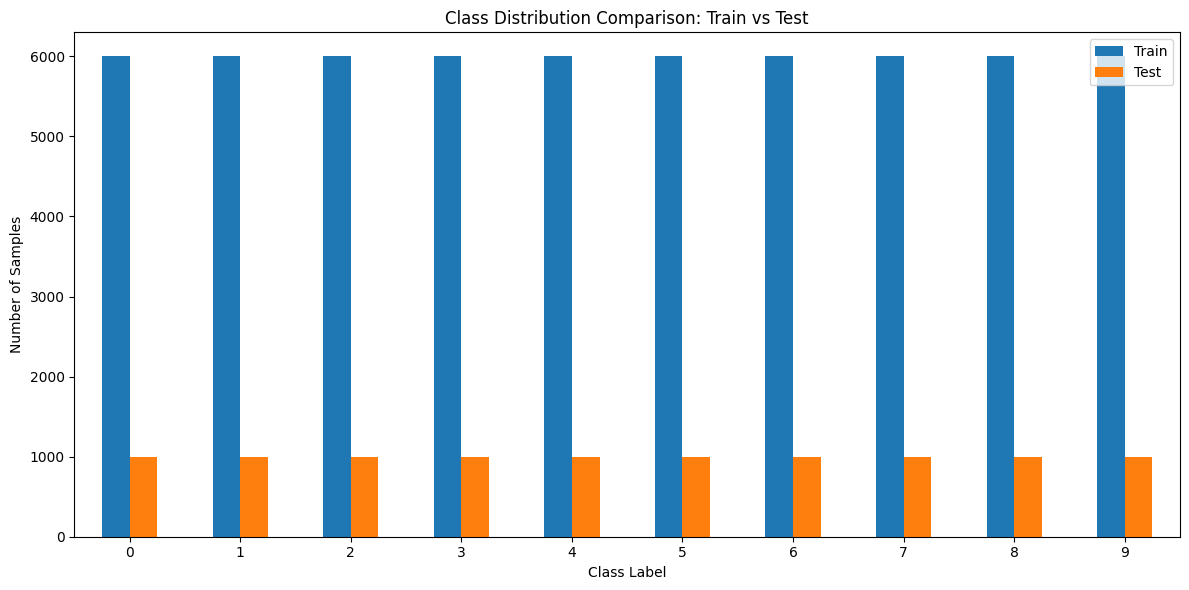

   Train  Test
0   6000  1000
1   6000  1000
2   6000  1000
3   6000  1000
4   6000  1000
5   6000  1000
6   6000  1000
7   6000  1000
8   6000  1000
9   6000  1000


In [8]:
# Compare class distribution between train and test
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Train': train_counts,
    'Test': test_counts
})

dist_df.plot(kind='bar', figsize=(12, 6))
plt.title('Class Distribution Comparison: Train vs Test')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print(dist_df)

# show sample rows from CSV

In [9]:
# Show sample rows from original CSV files
print("Sample rows from fashion-mnist_train.csv:")
display(train_df.head())

print("Sample rows from fashion-mnist_test.csv:")
display(test_df.head())

Sample rows from fashion-mnist_train.csv:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Sample rows from fashion-mnist_test.csv:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# show one sample vector (train & test)

In [10]:
# Show one sample vector from train set
sample_idx = 0

print("One sample from TRAIN CSV:")
print("Label:", train_df.iloc[sample_idx, 0])
print("First 20 pixel values:", train_df.iloc[sample_idx, 1:21].tolist())
print("Vector length:", len(train_df.iloc[sample_idx, 1:].tolist()))

One sample from TRAIN CSV:
Label: 2
First 20 pixel values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Vector length: 784


In [11]:
# Show one sample vector from test set
sample_idx = 0

print("One sample from TEST CSV:")
print("Label:", test_df.iloc[sample_idx, 0])
print("First 20 pixel values:", test_df.iloc[sample_idx, 1:21].tolist())
print("Vector length:", len(test_df.iloc[sample_idx, 1:].tolist()))

One sample from TEST CSV:
Label: 0
First 20 pixel values: [0, 0, 0, 0, 0, 0, 0, 9, 8, 0, 0, 34, 29, 7, 0, 11, 24, 0, 0, 3]
Vector length: 784


# example images from each class

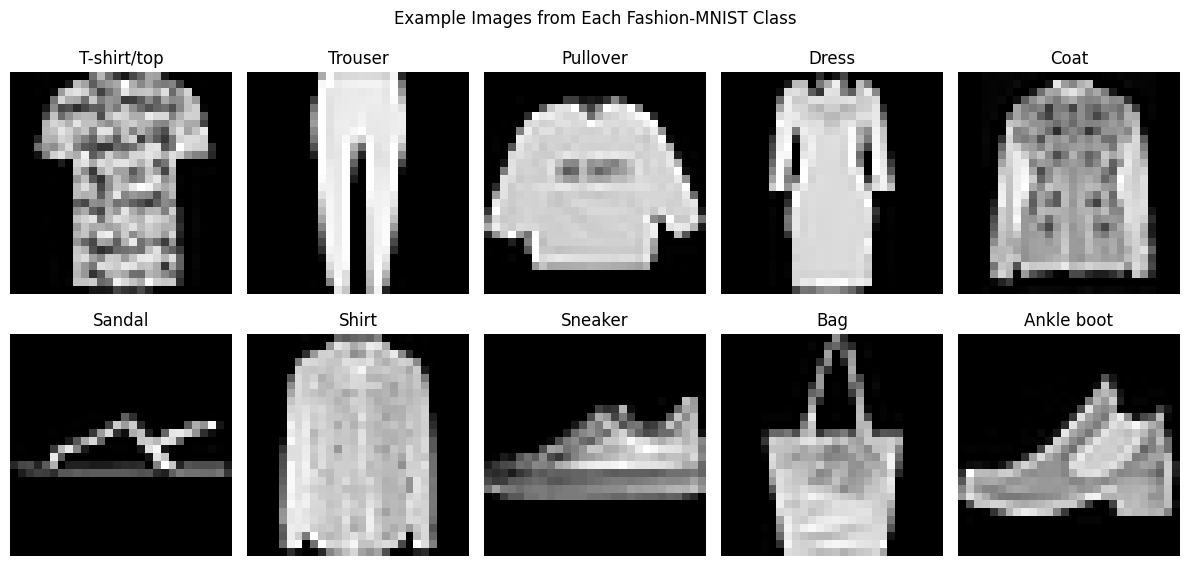

In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Hiển thị 10 ảnh đại diện (một ảnh cho mỗi lớp)
plt.figure(figsize=(12, 6))
for i in range(10):
    # Tìm index đầu tiên của lớp i
    idx = np.where(y_train == i)[0][0]
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Example Images from Each Fashion-MNIST Class')
plt.tight_layout()
plt.show()

In [5]:
X_train_raw = train_df.iloc[:, 1:].values.astype('float32')
y_train_raw = train_df.iloc[:, 0].values
X_test_raw  = test_df.iloc[:, 1:].values.astype('float32')
y_test      = test_df.iloc[:, 0].values

print(f"Original train shape: {X_train_raw.shape}, Test shape: {X_test_raw.shape}")

Original train shape: (60000, 784), Test shape: (10000, 784)


# pixel intensity distribution

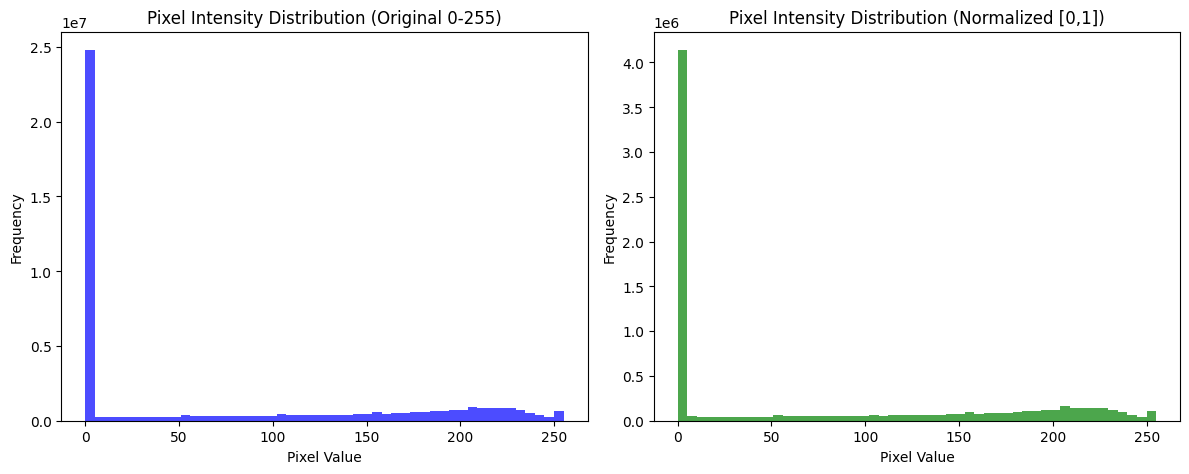

In [ ]:
# Pixel intensity distribution (train & test)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X_train_raw.ravel(), bins=50, color='blue', alpha=0.7)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(X_test_raw.ravel(), bins=50, color='green', alpha=0.7)
plt.title('Pixel Intensity Distribution')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
